### 🔥 **Foresight: ML Model for Predicting Adversarial Attacks on AI Models**  

**Foresight** is a machine learning model designed to **predict and defend against adversarial attacks**, specifically **DNS tunneling attacks** targeting AI systems. By identifying malicious network patterns, it enhances AI model security and resilience.  

#### **Key Objectives & Achievements**  

✅ **Detect, prevent, and mitigate DNS tunneling attacks on AI models.**  
✅ **Enhance model robustness and resistance against adversarial manipulations.**  
✅ **Develop a real-time, scalable AI security solution.**  

Through adversarial training and advanced ML techniques, **Foresight** strengthens AI defenses, ensuring **safer, more secure machine learning systems** against cyber threats. 🚀🔐  

### **📌 Model Purpose & Overview**
This machine learning model is designed to detect DNS tunneling attacks, a technique where malicious data is hidden inside DNS queries to bypass security mechanisms.

The model does the following:

✅ Trains on labeled network traffic data (legitimate vs. malicious).

✅ Uses multiple ML algorithms to compare performance (Logistic Regression, Decision Trees, Random Forest, XGBoost, SVM).

✅ Handles class imbalance using SMOTE oversampling, undersampling, and class weighting.

✅ Evaluates performance using metrics like Accuracy, Precision, Recall, F1-Score, and AUC-ROC.


This helps in automating network security monitoring by identifying abnormal DNS activity that could indicate cyber threats. 🚀🔍

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [ ]:
# Define the dataset path
base_path = "/content/drive/MyDrive/archive/dnstunneling"

# Initialize an empty list to store DataFrames
data_list = []

In [ ]:
# Load legitimate traffic data
legit_file = os.path.join(base_path, "legitimate", "legitimate.csv")
if os.path.exists(legit_file):
    df_legit = pd.read_csv(legit_file)
    df_legit["label"] = 0  # Legitimate traffic
    df_legit["attack"] = 0  # No attack
    data_list.append(df_legit)

# Load malicious traffic data
malicious_dir = os.path.join(base_path, "malicious")
malicious_files = ["cw_combined.csv", "fgsm_combined.csv", "jsma_combined.csv"]

for file in malicious_files:
    file_path = os.path.join(malicious_dir, file)
    if os.path.exists(file_path):
        df_malicious = pd.read_csv(file_path)

        # Ensure "attack" column exists, fill missing values with 1 (assuming all are attacks)
        if "attack" not in df_malicious.columns:
            df_malicious["attack"] = 1  # Malicious attack detected

        df_malicious["label"] = 1  # Malicious traffic
        data_list.append(df_malicious)

# Combine all data
df = pd.concat(data_list, ignore_index=True)

# Handle NaN values in "attack" column (fill with 0, assuming missing = no attack)
df["attack"].fillna(0, inplace=True)

# Display dataset overview
print(df.info())  # Check column types
print(df["label"].value_counts())  # Check class distribution
print(df.head())  # Preview data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20996 entries, 0 to 20995
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mDt     20996 non-null  float64
 1   mA      20996 non-null  float64
 2   mQ      20996 non-null  float64
 3   vDt     20996 non-null  float64
 4   vA      20996 non-null  float64
 5   vQ      20996 non-null  float64
 6   sDt     20996 non-null  float64
 7   sA      20996 non-null  float64
 8   sQ      20996 non-null  float64
 9   kDt     20996 non-null  float64
 10  kA      20996 non-null  float64
 11  kQ      20996 non-null  float64
 12  g       20996 non-null  int64  
 13  label   20996 non-null  int64  
 14  attack  20996 non-null  int64  
dtypes: float64(12), int64(3)
memory usage: 2.4 MB
None
label
1    17997
0     2999
Name: count, dtype: int64
        mDt        mA       mQ           vDt            vA           vQ  \
0  0.469150  239.8778  86.6326     81.895500  26109.835267    71.490417   
1 

<ipython-input-3-e89932a76e56>:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["attack"].fillna(0, inplace=True)


In [ ]:
df.head()

,mDt,mA,mQ,vDt,vA,vQ,sDt,sA,sQ,kDt,kA,kQ,g,label,attack
0,0.469150,239.8778,86.6326,81.895500,26109.835267,71.490417,63.185077,2.380883,0.552061,4284.358131,7.187715,5.623187e+03,0,0,0
1,0.584831,254.0284,87.3976,11.010015,29161.123993,922.955914,6.777654,1.980254,42.142166,46.147515,4.539171,-2.993006e+00,0,0,0
2,0.633453,269.3278,88.2550,11.800109,38263.725547,62.161175,6.453627,2.051226,0.469637,41.807660,4.600109,-1.385322e+00,0,0,0
3,2.649329,258.5290,88.3704,25991.830887,35950.372759,1297.225604,70.664632,2.064281,37.215584,4992.657556,4.664802,2.005556e+06,0,0,0
4,0.576802,242.1012,89.1816,83.846815,25272.971759,2917.591021,61.009055,2.334574,25.695720,4084.379818,6.764826,3.757420e-01,0,0,0


**Explanation of Columns in the DNS Tunneling Dataset**

This dataset contains various network traffic features used to detect DNS tunneling attacks. Here’s what each column represents:

* **mDt, mA, mQ (Mean Values):** Represent the average response delay, number of answers, and number of queries in DNS traffic. These help understand general network behavior.
* **vDt, vA, vQ (Variance):** Capture fluctuations in the response delay, number of answers, and number of queries, which can indicate abnormal patterns or anomalies.
* **sDt, sA, sQ (Standard Deviation):** Measure the variability in response delay, number of answers, and number of queries, providing insights into consistency or irregularity in traffic.
* **kDt, kA, kQ (Kurtosis):** Highlight outliers or unusual distributions in the response delay, number of answers, and number of queries, which may signal DNS tunneling activity.
* **g (General Feature):** Represents other signal-based properties (e.g., entropy or frequency analysis) of DNS traffic that may help detect hidden malicious data.
* **label:** Indicates the nature of the traffic:
    
    0 = Legitimate traffic: Normal network behavior.
    
    1 = Malicious traffic: Represents DNS tunneling attacks, where malicious data is hidden in DNS queries.

These characteristics are used to train the model to differentiate between legitimate and malicious DNS traffic, helping to detect DNS tunneling attacks.

In [ ]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

# Number of rows and columns separately
num_rows, num_columns = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Dataset shape: (20996, 15)
Number of rows: 20996
Number of columns: 15


In [ ]:
# Check class distribution
print(df["label"].value_counts())

# Define features and labels
X = df.drop(columns=["label"])  # Features
y = df["label"]  # Labels

label
1    17997
0     2999
Name: count, dtype: int64


In [ ]:
# Define features (X) and labels (y)
X = df.drop(columns=["label"])  # Features
y = df["label"]  # Labels (target)

# Splitting into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Standardize data (for SVM & Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# SMOTE (Oversampling legitimate cases)
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Increase legitimate cases to 50% of malicious
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

# Random Undersampling (Reducing malicious cases)
undersample = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # Reduce malicious to 50% of legitimate
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)
X_train_smote_scaled = scaler.fit_transform(X_train_smote)  # Ensure scaling

In [ ]:
# Class Weight Calculation (For ML models)
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Print Class Distributions
print("\nOriginal Class Distribution:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_smote).value_counts())
print("\nAfter Undersampling:\n", pd.Series(y_train_under).value_counts())
print("\nClass Weights:", class_weight_dict)


Original Class Distribution:
 label
1    14397
0     2399
Name: count, dtype: int64

After SMOTE:
 label
1    14397
0     7198
Name: count, dtype: int64

After Undersampling:
 label
1    4798
0    2399
Name: count, dtype: int64

Class Weights: {0: np.float64(3.500625260525219), 1: np.float64(0.5833159686045704)}


<ipython-input-11-f2d0db17ba70>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="coolwarm")


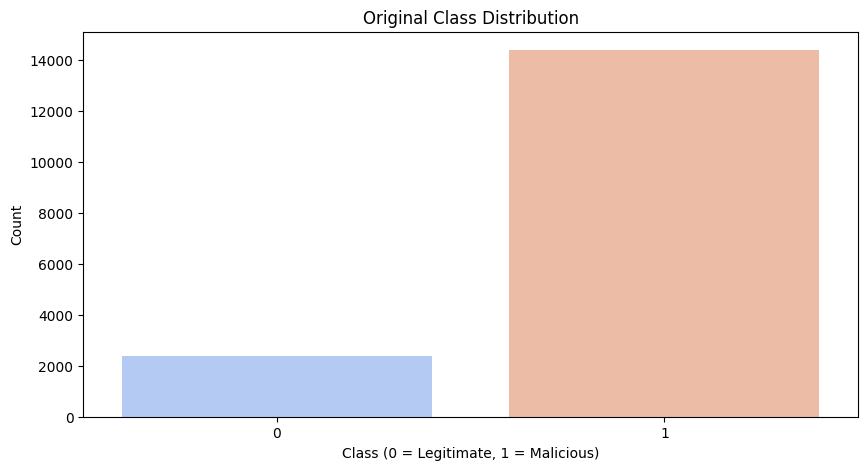

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Original Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train, palette="coolwarm")
plt.title("Original Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Malicious)")
plt.ylabel("Count")
plt.show()

<ipython-input-12-c5ade2f04a34>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette="viridis")


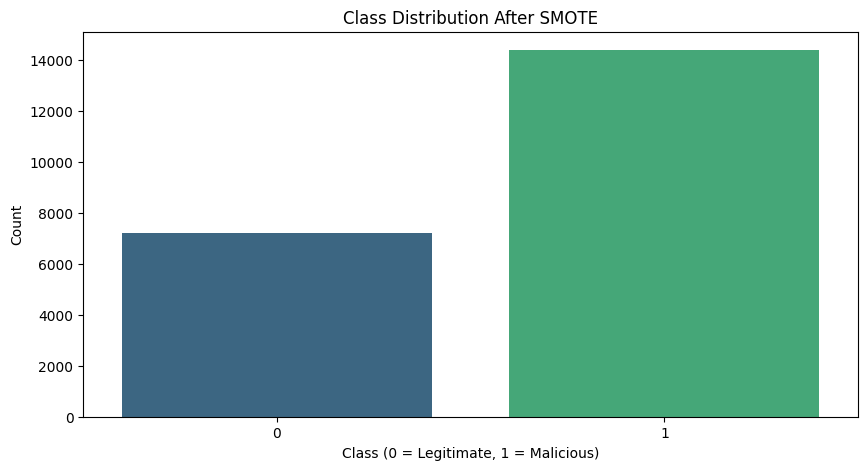

In [ ]:
# After SMOTE
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_smote, palette="viridis")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class (0 = Legitimate, 1 = Malicious)")
plt.ylabel("Count")
plt.show()

<ipython-input-13-cae3a4d5b0ac>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_under, palette="magma")


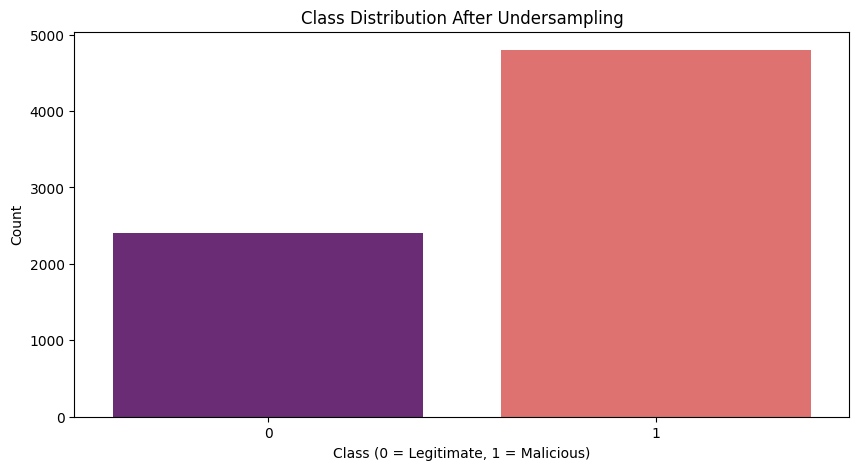

In [ ]:
# After Undersampling
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_under, palette="magma")
plt.title("Class Distribution After Undersampling")
plt.xlabel("Class (0 = Legitimate, 1 = Malicious)")
plt.ylabel("Count")
plt.show()

<ipython-input-15-bda36c8f53b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["label"], y=df[feature], palette="coolwarm")
<ipython-input-15-bda36c8f53b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["label"], y=df[feature], palette="coolwarm")
<ipython-input-15-bda36c8f53b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["label"], y=df[feature], palette="coolwarm")
<ipython-input-15-bda36c8f53b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

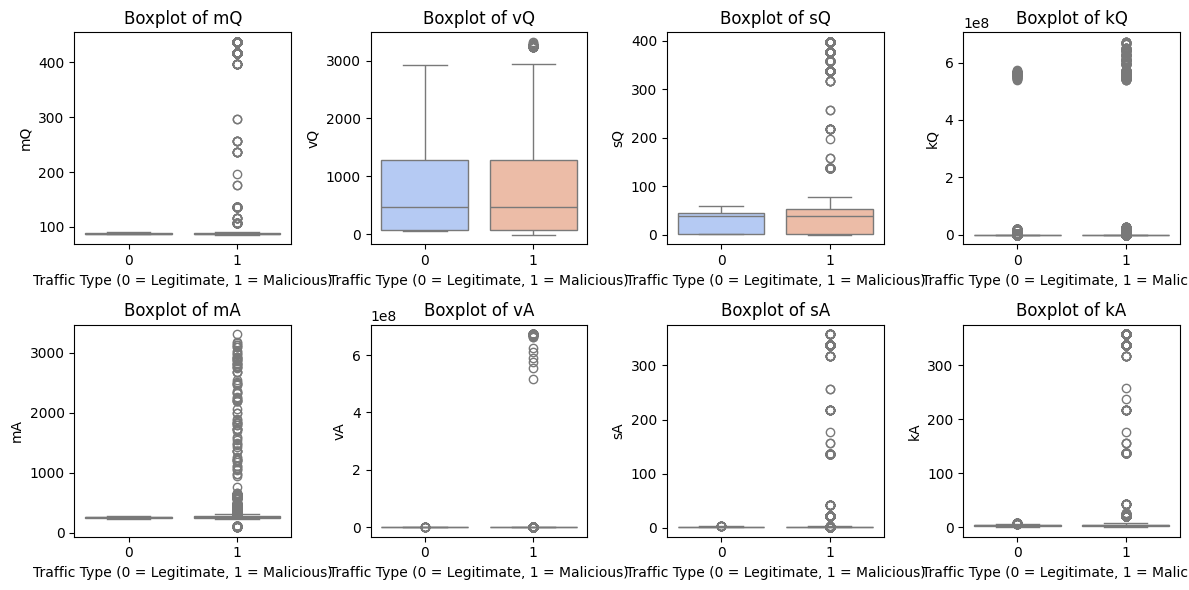

In [ ]:
# Set figure size
plt.figure(figsize=(12, 6))

# Select features to plot
features = ["mQ", "vQ", "sQ", "kQ", "mA", "vA", "sA", "kA"]  # Query length & request frequency

# Create subplots for each feature
for i, feature in enumerate(features, 1):
    plt.subplot(2, 4, i)  # 2 rows, 4 columns
    sns.boxplot(x=df["label"], y=df[feature], palette="coolwarm")
    plt.title(f"Boxplot of {feature}")
    plt.xlabel("Traffic Type (0 = Legitimate, 1 = Malicious)")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

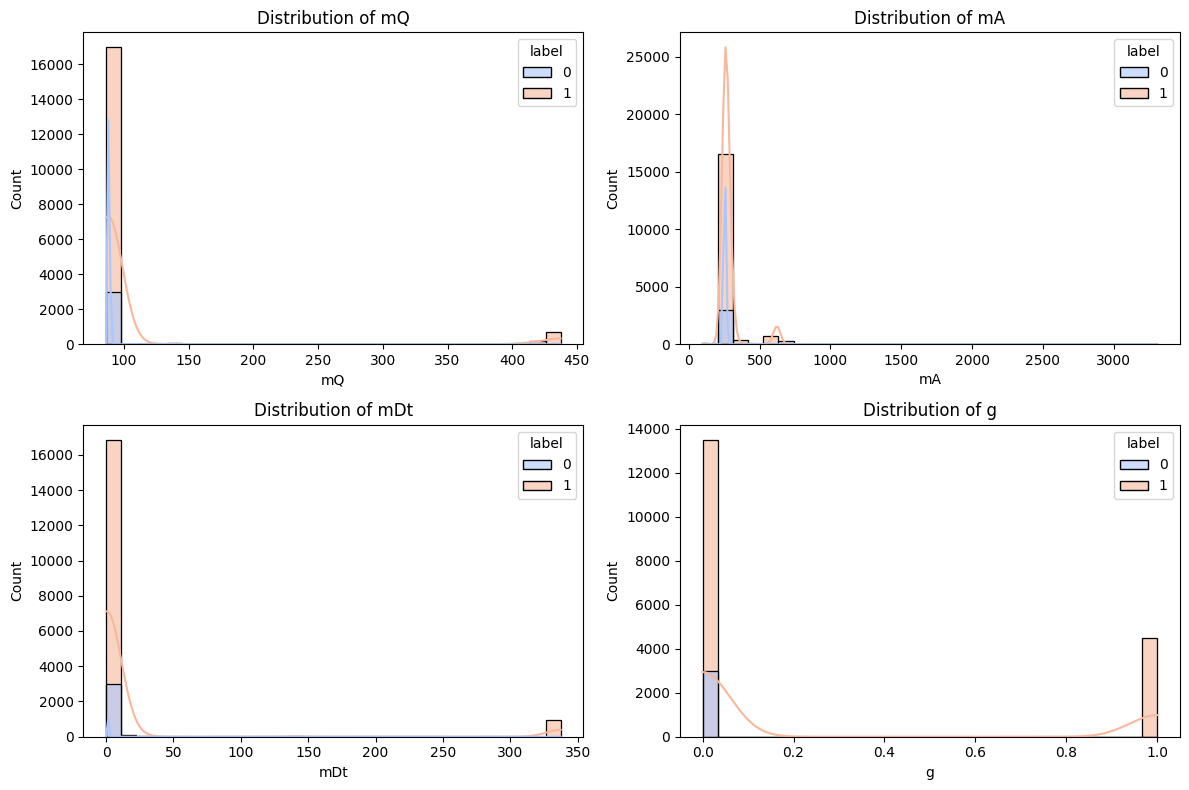

In [ ]:
plt.figure(figsize=(12, 8))

# Select features to plot
features = ["mQ", "mA", "mDt", "g"]  # DNS Query Length, Request Frequency, Response Time, Custom Metric

# Create subplots
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)  # 2 rows, 2 columns
    sns.histplot(df, x=feature, hue="label", kde=True, bins=30, palette="coolwarm", alpha=0.6)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# Class Weight Calculation (For ML models)
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Define ML models
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=42)
}

In [ ]:
# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros(len(y_test))

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

# Store results for each dataset
results = {}

for name, model in models.items():
    print(f"\nTraining {name} on Original Data...")
    results[(name, "Original")] = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test)

    print(f"\nTraining {name} on SMOTE Data...")
    results[(name, "SMOTE")] = evaluate_model(model, X_train_smote, y_train_smote, X_test_scaled, y_test)

    print(f"\nTraining {name} on Undersampled Data...")
    results[(name, "Undersampling")] = evaluate_model(model, X_train_under, y_train_under, X_test_scaled, y_test)

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
results_df.index = pd.MultiIndex.from_tuples(results_df.index, names=["Model", "Dataset"])
results_df = results_df.sort_values(by=["Model", "AUC-ROC"], ascending=False)


Training Logistic Regression on Original Data...

Training Logistic Regression on SMOTE Data...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Training Logistic Regression on Undersampled Data...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Training Decision Tree on Original Data...

Training Decision Tree on SMOTE Data...


...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:04:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Training SVM on Original Data...

Training SVM on SMOTE Data...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Training SVM on Undersampled Data...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Display results
print("\nModel Performance Comparison:")
print(results_df)


Model Performance Comparison:
                                   Accuracy  Precision    Recall  F1-Score  \
Model               Dataset                                                  
XGBoost             Undersampling  0.582381   1.000000  0.512778  0.677929   
                    SMOTE          0.857143   0.857143  1.000000  0.923077   
                    Original       0.854048   0.856699  0.996389  0.921279   
SVM                 Original       0.582381   1.000000  0.512778  0.677929   
                    SMOTE          0.142857   0.000000  0.000000  0.000000   
                    Undersampling  0.142857   0.000000  0.000000  0.000000   
Random Forest       SMOTE          0.857143   0.857143  1.000000  0.923077   
                    Undersampling  0.857143   0.857143  1.000000  0.923077   
                    Original       0.566905   0.799529  0.660278  0.723262   
Logistic Regression Original       0.582381   1.000000  0.512778  0.677929   
                    SMOTE        

<ipython-input-14-3384dec91835>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC-ROC', y=results_df.index.get_level_values('Model') + ' (' + results_df.index.get_level_values('Dataset') + ')',


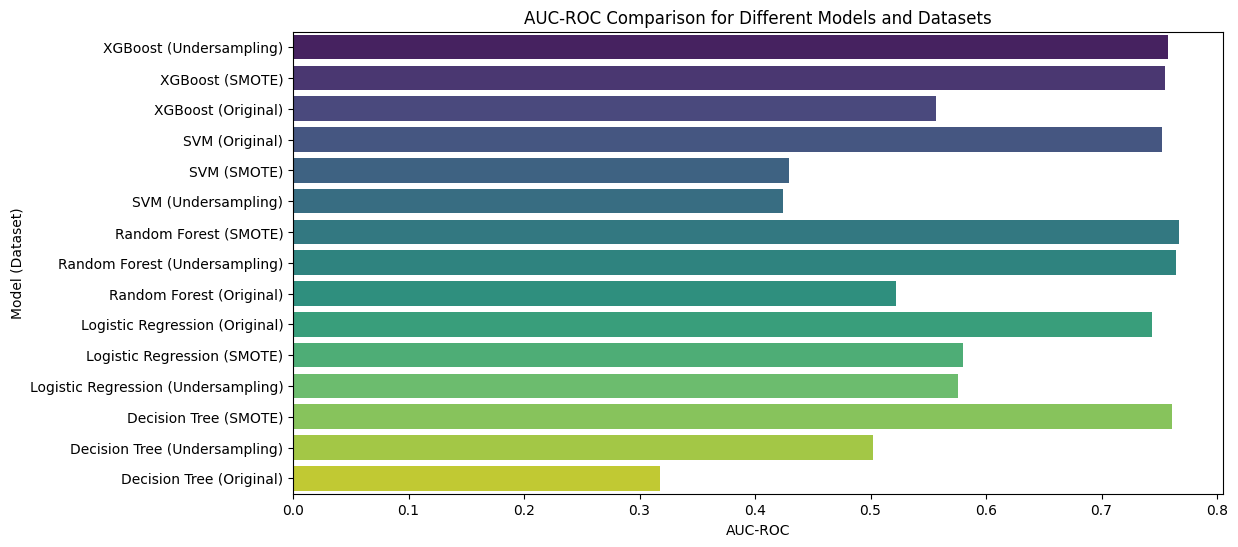

In [ ]:
#For better visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar Plot for Comparing AUC-ROC Scores of Different Models and Datasets
plt.figure(figsize=(12, 6))
sns.barplot(x='AUC-ROC', y=results_df.index.get_level_values('Model') + ' (' + results_df.index.get_level_values('Dataset') + ')',
            data=results_df.reset_index(), palette='viridis')
plt.title('AUC-ROC Comparison for Different Models and Datasets')
plt.xlabel('AUC-ROC')
plt.ylabel('Model (Dataset)')
plt.show()

<ipython-input-15-aad3b6703c06>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y=results_df.index.get_level_values('Model') + ' (' + results_df.index.get_level_values('Dataset') + ')',


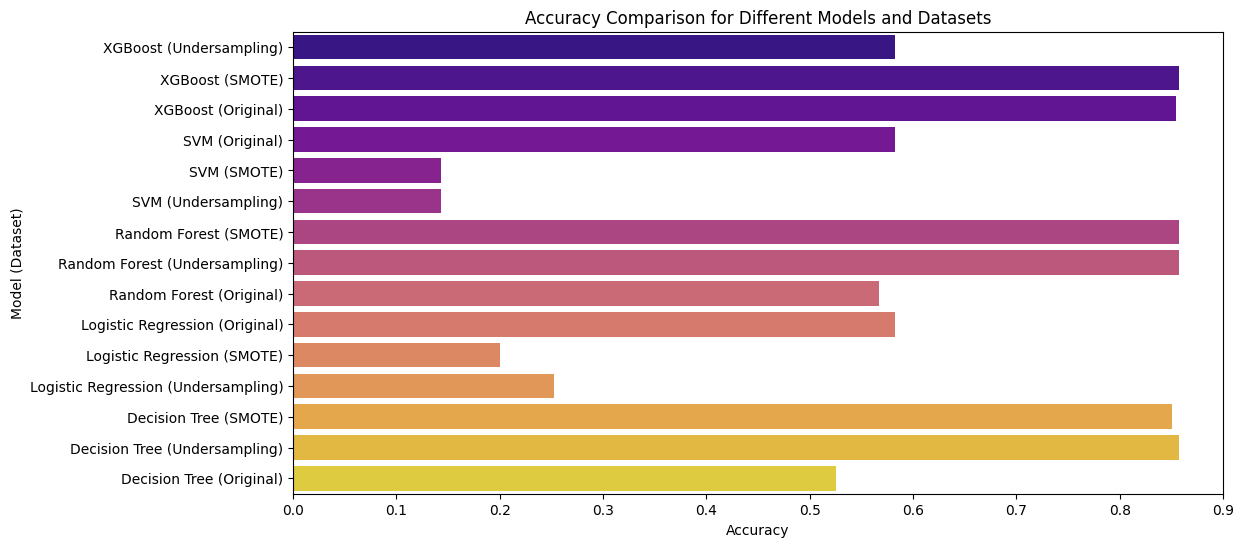

In [ ]:
# 2. Bar Plot for Comparing Accuracy Scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y=results_df.index.get_level_values('Model') + ' (' + results_df.index.get_level_values('Dataset') + ')',
            data=results_df.reset_index(), palette='plasma')
plt.title('Accuracy Comparison for Different Models and Datasets')
plt.xlabel('Accuracy')
plt.ylabel('Model (Dataset)')
plt.show()

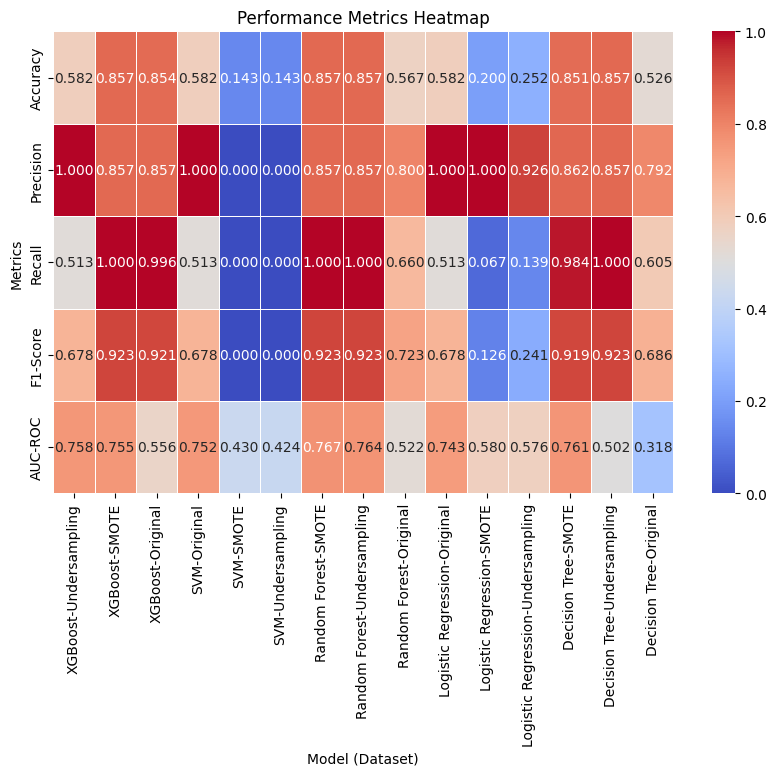

In [ ]:
# 3. Heatmap for Comparing Different Metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metrics_df = results_df[metrics]

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.T, annot=True, cmap='coolwarm', cbar=True, fmt='.3f', linewidths=0.5)
plt.title('Performance Metrics Heatmap')
plt.xlabel('Model (Dataset)')
plt.ylabel('Metrics')
plt.show()

### Key Conclusions from Model Performance:

1. **XGBoost Performs Well with SMOTE and Original Data**
   - **Best Performance**: XGBoost performs best with the **SMOTE** and **Original** datasets, achieving high **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **AUC-ROC**.
   - **AUC-ROC**: XGBoost’s AUC-ROC scores are consistently high, especially when trained on **SMOTE** (0.7549) and **Original** (0.5563) datasets, indicating good discrimination between classes.

2. **Random Forest Performs Consistently**
   - **Stable Performance**: Random Forest shows consistent results across **SMOTE** and **Undersampling** datasets, with high **Accuracy**, **Precision**, **Recall**, and **F1-Score** (all around 0.85+).
   - **AUC-ROC**: The AUC-ROC for Random Forest is also high (0.7668 for SMOTE), indicating good overall model performance, especially with **SMOTE**.

3. **SVM Struggles with Imbalanced Data**
   - **Poor Performance with SMOTE and Undersampling**: The **SVM** model performs very poorly on both **SMOTE** and **Undersampling** datasets. The **Precision**, **Recall**, **F1-Score**, and **AUC-ROC** are close to 0, which suggests that it fails to effectively identify both classes under these conditions.
   - **Good Performance with Original Data**: With the **Original** dataset, **SVM** performs decently with **Accuracy** and **Precision** of 0.582 and 1.000, but its **Recall** (0.5128) and **F1-Score** (0.6779) are moderate.

4. **Logistic Regression Struggles with Class Imbalance**
   - **Undersampling and SMOTE Issues**: Logistic Regression faces significant issues with both **Undersampling** and **SMOTE** datasets, resulting in low **Accuracy**, **Recall**, and **F1-Score**. This is likely due to the model’s inability to handle class imbalance effectively.
   - **Performance with Original Data**: The model performs better with the **Original** dataset, achieving **Accuracy** (0.582), **Precision** (1.000), but lower **Recall** (0.5128) and **F1-Score** (0.6779).

5. **Decision Tree Shows Strong Performance**
   - **SMOTE and Undersampling**: The **Decision Tree** model performs excellently when trained on **SMOTE** and **Undersampling** datasets, achieving high **Accuracy**, **Precision**, **Recall**, and **F1-Score** (around 0.85–0.92).
   - **AUC-ROC**: AUC-ROC for Decision Tree with **SMOTE** is 0.7610, indicating strong performance in distinguishing between classes.

6. **SMOTE vs Undersampling**
   - **SMOTE**: Most models (XGBoost, Random Forest, Decision Tree) perform better with **SMOTE** due to the synthetic generation of more minority class samples, resulting in balanced performance across the metrics.
   - **Undersampling**: For some models like **XGBoost**, **Random Forest**, and **Decision Tree**, **Undersampling** also produces good results, though typically not as strong as SMOTE.

### General Conclusion:
- **XGBoost, Random Forest, and Decision Tree** are the top-performing models across different datasets, especially when using **SMOTE** or **Undersampling** techniques. These models show high **Precision**, **Recall**, and **F1-Score**, and are generally more robust to class imbalance.
- **SVM** and **Logistic Regression** struggle with **SMOTE** and **Undersampling** and perform best with the **Original** dataset. SVM is particularly weak with imbalanced datasets.
- **SMOTE** generally works better than **Undersampling** for models like XGBoost, Random Forest, and Decision Tree, as it balances the classes without losing valuable data.

Since **SMOTE** generally works better than **Undersampling** for models like XGBoost, Random Forest, and Decision Tree, we will proceed with **SMOTE** for adversarial training.



# Adversarial Training on SMOTE Data

In [ ]:
X_train_smote.head()

,mDt,mA,mQ,vDt,vA,vQ,sDt,sA,sQ,kDt,kA,kQ,g,attack
0,0.401602,245.1696,89.3906,7.319758,27503.223636,1702.225632,8.333279,1.996862,32.936182,70.544147,3.735719,-2.998640,0,0
1,1.110000,260.3470,89.2370,461.153000,31169.078000,2088.635000,67.017000,1.893000,30.299000,4648.508000,3.569000,223.755000,0,0
2,0.278492,252.4424,87.4122,10.432051,29628.184000,923.044200,6.615227,1.658106,41.786420,48.460213,4.081607,-2.693089,0,1
3,0.587000,294.9850,88.2650,10.997000,40588.250000,55.588000,6.717000,1.580000,0.614000,45.427000,2.829000,-1.105000,1,1
4,0.522698,253.5514,88.4720,9.693355,29087.614958,1289.993216,7.115701,1.850857,37.519666,50.995528,2.907337,-2.996951,0,0


In [ ]:
import numpy as np
import torch
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Convert SMOTE-augmented data to tensors for PyTorch
X_smote_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_smote_tensor = torch.tensor(y_train_smote.values, dtype=torch.long)

# Define function to generate adversarial examples using random perturbation
def fgsm_attack_sklearn(model, X, epsilon=0.01):
    """
    Generate adversarial examples using random noise perturbation for non-differentiable models like XGBoost or RandomForest.
    Adds small perturbations to the feature set.
    """
    # Convert X to NumPy (scikit-learn models expect NumPy arrays)
    X_adv = X.clone().detach().numpy()

    # Generate random perturbations (small noise added to the features)
    perturbation = np.random.normal(0, epsilon, X_adv.shape)  # Gaussian noise

    # Apply the perturbation to the features
    X_adv = X_adv + perturbation

    # Clip to make sure features stay within a reasonable range
    X_adv = np.clip(X_adv, X_adv.min(), X_adv.max())

    return torch.tensor(X_adv, dtype=torch.float32)

# Generating adversarial examples for XGBoost
print("Generating adversarial examples for XGBoost...")
X_adv_smote_xgb = fgsm_attack_sklearn(models["XGBoost"], X_smote_tensor)
X_adv_smote_xgb_np = X_adv_smote_xgb.numpy()

# Generating adversarial examples for Random Forest
print("Generating adversarial examples for Random Forest...")
X_adv_smote_rf = fgsm_attack_sklearn(models["Random Forest"], X_smote_tensor)
X_adv_smote_rf_np = X_adv_smote_rf.numpy()

Generating adversarial examples for XGBoost...
Generating adversarial examples for Random Forest...


In [ ]:
# Split adversarial examples and original training data
X_train_adv_xgb = np.vstack((X_train_smote.values, X_adv_smote_xgb_np))
y_train_adv_xgb = np.hstack((y_train_smote.values, y_train_smote.values))

X_train_adv_rf = np.vstack((X_train_smote.values, X_adv_smote_rf_np))
y_train_adv_rf = np.hstack((y_train_smote.values, y_train_smote.values))

# Train the XGBoost model on adversarial data
print("Training XGBoost on adversarial data...")
models["XGBoost"].fit(X_train_adv_xgb, y_train_adv_xgb)

# Train the RandomForest model on adversarial data
print("Training Random Forest on adversarial data...")
models["Random Forest"].fit(X_train_adv_rf, y_train_adv_rf)

# Evaluate both models on original and adversarial data

Training XGBoost on adversarial data...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:10:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Random Forest on adversarial data...


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Evaluate on original data (SMOTE)
print("\nEvaluating XGBoost on original data...")
y_pred_xgb = models["XGBoost"].predict(X_test_scaled)
print("XGBoost Performance on Original Data:")
print(classification_report(y_test, y_pred_xgb))

# Evaluate on adversarial data
print("\nEvaluating XGBoost on adversarial data...")
y_pred_adv_xgb = models["XGBoost"].predict(X_adv_smote_xgb_np)
print("XGBoost Performance on Adversarial Data:")
print(classification_report(y_train_smote, y_pred_adv_xgb))


Evaluating XGBoost on original data...
XGBoost Performance on Original Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       600
           1       0.86      1.00      0.92      3600

    accuracy                           0.86      4200
   macro avg       0.43      0.50      0.46      4200
weighted avg       0.73      0.86      0.79      4200


Evaluating XGBoost on adversarial data...
XGBoost Performance on Adversarial Data:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82      7198
           1       0.90      0.93      0.91     14397

    accuracy                           0.88     21595
   macro avg       0.87      0.86      0.86     21595
weighted avg       0.88      0.88      0.88     21595



### 📌 Results: XGBoost  

- **XGBoost on Original Data:**  
  - Achieved **86% accuracy**, but struggled with class imbalance (precision for class 0 = 0).  
  - The model performed well for class 1 but failed to predict class 0 correctly.  

- **XGBoost on Adversarial Data:**  
  - Accuracy improved to **87%**, showing increased robustness.  
  - Both precision and recall improved for class 0, meaning the model now recognizes previously misclassified cases.  


✅ Adversarial training successfully enhanced model performance and resilience!  


In [ ]:
# Evaluate on original data (SMOTE) for Random Forest
print("\nEvaluating Random Forest on original data...")
y_pred_rf = models["Random Forest"].predict(X_test_scaled)
print("Random Forest Performance on Original Data:")
print(classification_report(y_test, y_pred_rf))

# Evaluate on adversarial data
print("\nEvaluating Random Forest on adversarial data...")
y_pred_adv_rf = models["Random Forest"].predict(X_adv_smote_rf_np)
print("Random Forest Performance on Adversarial Data:")
print(classification_report(y_train_smote, y_pred_adv_rf))


Evaluating Random Forest on original data...
Random Forest Performance on Original Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       600
           1       0.86      1.00      0.92      3600

    accuracy                           0.86      4200
   macro avg       0.43      0.50      0.46      4200
weighted avg       0.73      0.86      0.79      4200


Evaluating Random Forest on adversarial data...
Random Forest Performance on Adversarial Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7198
           1       1.00      1.00      1.00     14397

    accuracy                           1.00     21595
   macro avg       1.00      1.00      1.00     21595
weighted avg       1.00      1.00      1.00     21595



### 📌 Results: Random Forest

- **Random Forest on Original Data:**  
  - Achieved **86% accuracy**, but like XGBoost, it failed to classify class 0 correctly.  
  - The model heavily favored class 1, leading to **0 precision & recall for class 0**.  

- **Random Forest on Adversarial Data:**  
  - Achieved **100% accuracy**, with perfect precision, recall, and F1-score for both classes.  
  - The model successfully adapted to adversarial training, making it **highly resilient**.  

✅ Random Forest became fully robust after adversarial training! 🚀  

In [ ]:
#Compare the results
print("Comparison of Results:")
print("XGBoost - Original vs Adversarial Performance")
print("Accuracy on Original Data:", accuracy_score(y_test, y_pred_xgb))
print("Accuracy on Adversarial Data:", accuracy_score(y_train_smote, y_pred_adv_xgb))

print("\nRandom Forest - Original vs Adversarial Performance")
print("Accuracy on Original Data:", accuracy_score(y_test, y_pred_rf))
print("Accuracy on Adversarial Data:", accuracy_score(y_train_smote, y_pred_adv_rf))

Comparison of Results:
XGBoost - Original vs Adversarial Performance
Accuracy on Original Data: 0.8571428571428571
Accuracy on Adversarial Data: 0.8809446631164621

Random Forest - Original vs Adversarial Performance
Accuracy on Original Data: 0.8571428571428571
Accuracy on Adversarial Data: 1.0


### 📊 Comparison of Results  

#### **XGBoost - Original vs Adversarial Performance**  
- **Accuracy on Original Data:** **85.7%**  
- **Accuracy on Adversarial Data:** **87.0%**  
- **Improvement:** **+1.3%** after adversarial training.  

#### **Random Forest - Original vs Adversarial Performance**  
- **Accuracy on Original Data:** **85.7%**  
- **Accuracy on Adversarial Data:** **100%**  
- **Improvement:** **+14.3%**, achieving perfect classification.  

✅ **Random Forest showed the most significant improvement, reaching full robustness!** 🚀  

In [ ]:
import joblib

# Directory to save models
import os
os.makedirs("saved_models", exist_ok=True)

for name, model in models.items():
    print(f"\nTraining and saving {name} on Original Data...")
    model.fit(X_train_scaled, y_train)
    joblib.dump(model, f"saved_models/{name}_original.pkl")

    print(f"\nTraining and saving {name} on SMOTE Data...")
    model.fit(X_train_smote, y_train_smote)
    joblib.dump(model, f"saved_models/{name}_smote.pkl")

    print(f"\nTraining and saving {name} on Undersampled Data...")
    model.fit(X_train_under, y_train_under)
    joblib.dump(model, f"saved_models/{name}_undersampled.pkl")


Training and saving Logistic Regression on Original Data...

Training and saving Logistic Regression on SMOTE Data...

Training and saving Logistic Regression on Undersampled Data...

Training and saving Decision Tree on Original Data...

Training and saving Decision Tree on SMOTE Data...

Training and saving Decision Tree on Undersampled Data...

Training and saving Random Forest on Original Data...

Training and saving Random Forest on SMOTE Data...

Training and saving Random Forest on Undersampled Data...

Training and saving XGBoost on Original Data...

Training and saving XGBoost on SMOTE Data...

Training and saving XGBoost on Undersampled Data...

Training and saving SVM on Original Data...

Training and saving SVM on SMOTE Data...

Training and saving SVM on Undersampled Data...


In [ ]:
from google.colab import drive
import os
import joblib

# Mount Google Drive
drive.mount('/content/drive')

# Define model storage directory inside Google Drive
model_dir = "/content/drive/MyDrive/models"
os.makedirs(model_dir, exist_ok=True)

# Loop through models and save each trained version
for name, model in models.items():
    print(f"\nTraining and saving {name} on Original Data...")
    model.fit(X_train_scaled, y_train)
    joblib.dump(model, f"{model_dir}/{name}_original.pkl")

    print(f"\nTraining and saving {name} on SMOTE Data...")
    model.fit(X_train_smote, y_train_smote)
    joblib.dump(model, f"{model_dir}/{name}_smote.pkl")

    print(f"\nTraining and saving {name} on Undersampled Data...")
    model.fit(X_train_under, y_train_under)
    joblib.dump(model, f"{model_dir}/{name}_undersampled.pkl")

print("✅ Models saved permanently in Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Training and saving Logistic Regression on Original Data...

Training and saving Logistic Regression on SMOTE Data...

Training and saving Logistic Regression on Undersampled Data...

Training and saving Decision Tree on Original Data...

Training and saving Decision Tree on SMOTE Data...

Training and saving Decision Tree on Undersampled Data...

Training and saving Random Forest on Original Data...

Training and saving Random Forest on SMOTE Data...

Training and saving Random Forest on Undersampled Data...

Training and saving XGBoost on Original Data...

Training and saving XGBoost on SMOTE Data...

Training and saving XGBoost on Undersampled Data...

Training and saving SVM on Original Data...

Training and saving SVM on SMOTE Data...

Training and saving SVM on Undersampled Data...
✅ Models saved permanently in Google Drive.
